# Garbage Classification using MobileNetV2


In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, applications, callbacks

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load Dataset (`image_dataset_from_directory`)

In [3]:
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/FINAL_MERGED_DATASET'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Create Training Dataset (80%)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    shuffle=True,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Create Validation Dataset (20%)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    shuffle=True,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print("Classes Found:", class_names)

Found 6320 files belonging to 4 classes.
Using 5056 files for training.
Found 6320 files belonging to 4 classes.
Using 1264 files for validation.
Classes Found: ['electronics', 'metal', 'paper', 'plastic']


## 2. Optimize Dataset Performance

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

## 3. Data Augmentation Pipeline

In [5]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip('horizontal'),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomTranslation(0.1, 0.1)
], name="data_augmentation")

## 4. Build Model with MobileNetV2

In [6]:
# MobileNetV2 expects inputs in range [-1, 1]
preprocess_input = applications.mobilenet_v2.preprocess_input

base_model = applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,588 (9.26 MB)

 Trainable params: 167,044 (652.52 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 5. Compile and Train (Head Layers)

In [7]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

callbacks_list = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    callbacks.ModelCheckpoint('best_garbage_model.keras', save_best_only=True, monitor='val_accuracy'),
    callbacks.ReduceLROnPlateau(factor=0.2, patience=3, min_lr=1e-6)
]

history = model.fit(train_dataset,
                    epochs=20,
                    validation_data=val_dataset,
                    callbacks=callbacks_list)

Epoch 1/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 991s 6s/step - accuracy: 0.8772 - loss: 0.3427 - val_accuracy: 0.9494 - val_loss: 0.1401 - learning_rate: 0.0010
Epoch 2/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 51s 325ms/step - accuracy: 0.9306 - loss: 0.1935 - val_accuracy: 0.9478 - val_loss: 0.1439 - learning_rate: 0.0010
Epoch 3/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 53s 337ms/step - accuracy: 0.9436 - loss: 0.1538 - val_accuracy: 0.9597 - val_loss: 0.1257 - learning_rate: 0.0010
Epoch 4/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 81s 329ms/step - accuracy: 0.9513 - loss: 0.1313 - val_accuracy: 0.9612 - val_loss: 0.1394 - learning_rate: 0.0010
Epoch 5/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 63s 401ms/step - accuracy: 0.9541 - loss: 0.1357 - val_accuracy: 0.9525 - val_loss: 0.1358 - learning_rate: 0.0010
Epoch 6/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 71s 334ms/step - accuracy: 0.9579 - loss: 0.1150 - val_accuracy: 0.9533 - val_loss: 0.1411 - learning_rate: 0.0010
Epoch 7/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 54s 344ms/step - accuracy: 0.965

In [ ]:
model.save('model.h5')

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('model.h5')

In [9]:
class_to_idx = {name: i for i, name in enumerate(class_names)}
print(class_to_idx)

{'electronics': 0, 'metal': 1, 'paper': 2, 'plastic': 3}


In [28]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = '/content/WhatsApp Image 2026-04-21 at 12.20.58 AM.jpeg'

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

# class names (عدّلها حسب مودلك لو مختلفة)
class_names = ['electronics',
               'metal', 'paper', 'plastic']

# get predicted index
pred_index = np.argmax(pred)
pred_class = class_names[pred_index]


print("Predicted Class:", pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Class: paper


## 6. Fine Tuning for Better Accuracy

In [29]:
base_model.trainable = True

# Freeze all layers except the last 30 for fine tuning
for layer in base_model.layers[:-30]:
  layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_fine = model.fit(train_dataset,
                         epochs=15,
                         validation_data=val_dataset,
                         callbacks=callbacks_list)

Epoch 1/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 59s 312ms/step - accuracy: 0.9270 - loss: 0.2029 - val_accuracy: 0.9597 - val_loss: 0.1473 - learning_rate: 1.0000e-05
Epoch 2/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 46s 291ms/step - accuracy: 0.9428 - loss: 0.1561 - val_accuracy: 0.9533 - val_loss: 0.1736 - learning_rate: 1.0000e-05
Epoch 3/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 46s 291ms/step - accuracy: 0.9597 - loss: 0.1143 - val_accuracy: 0.9533 - val_loss: 0.1768 - learning_rate: 1.0000e-05
Epoch 4/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 82s 294ms/step - accuracy: 0.9541 - loss: 0.1214 - val_accuracy: 0.9565 - val_loss: 0.1638 - learning_rate: 2.0000e-06
Epoch 5/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 83s 300ms/step - accuracy: 0.9583 - loss: 0.1124 - val_accuracy: 0.9581 - val_loss: 0.1538 - learning_rate: 2.0000e-06


In [51]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = '/content/tabak.jpeg'

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

# class names (عدّلها حسب مودلك لو مختلفة)
class_names = ['electronics',
               'metal', 'paper', 'plastic']

# get predicted index
pred_index = np.argmax(pred)
pred_class = class_names[pred_index]


print("Predicted Class:", pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Class: metal


In [45]:
model.save('/content/drive/MyDrive/ecocycle.keras')

## 7. Evaluate and Plot Results

40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 249ms/step - accuracy: 0.9597 - loss: 0.1473
Final Validation Accuracy: 0.9597


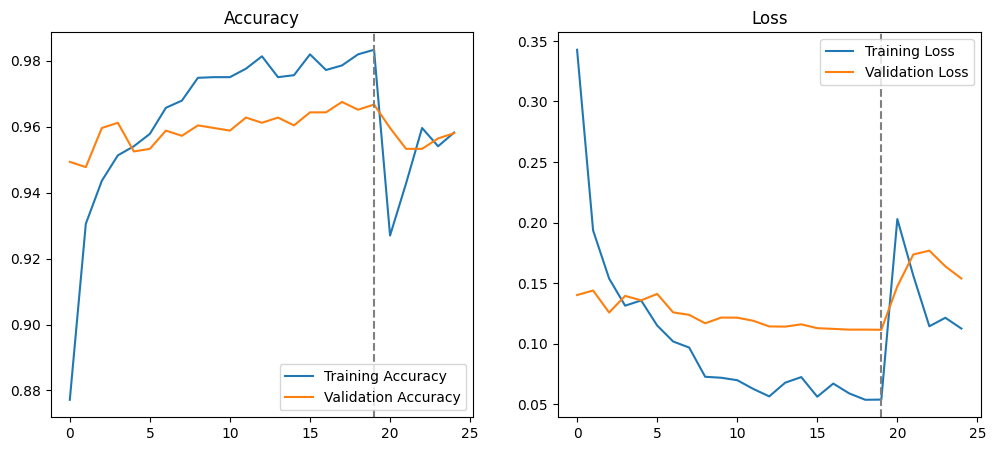

In [46]:
loss, accuracy = model.evaluate(val_dataset)
print(f'Final Validation Accuracy: {accuracy:.4f}')

def plot_learning_curves(history, history_fine):
    acc = history.history['accuracy'] + history_fine.history['accuracy']
    val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

    loss = history.history['loss'] + history_fine.history['loss']
    val_loss = history.history['val_loss'] + history_fine.history['val_loss']

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.axvline(x=len(history.history['accuracy'])-1, color='gray', linestyle='--')
    plt.legend(loc='lower right')
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.axvline(x=len(history.history['loss'])-1, color='gray', linestyle='--')
    plt.legend(loc='upper right')
    plt.title('Loss')
    plt.show()

plot_learning_curves(history, history_fine)